<a href="https://colab.research.google.com/github/elvissoares/COQ878-QuiQuaComp/blob/main/notebooks/notebook_Aula_MACE_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Force Field usando MACE e ASE no Google Colab

Autor: [Prof. Elvis do A. Soares](https://github.com/elvissoares)

Contato: [elvis@peq.coppe.ufrj.br](mailto:elvis@peq.coppe.ufrj.br) - [Programa de Engenharia Química, PEQ/COPPE, UFRJ, Brasil](https://www.peq.coppe.ufrj.br/)

---

Nesse tutorial iremos aprender como melhorar modelos de MLIP usando modelos de estado da arte como [foundation models](https://mace-docs.readthedocs.io/en/latest/guide/foundation_models.html) baseados na arquitetura [MACE](https://mace-docs.readthedocs.io/en/latest/index.html). Discutiremos também como realizar o [fine tunning](https://mace-docs.readthedocs.io/en/latest/guide/finetuning.html) do modelo com novos cálculos ab initio realizados com VASP.

> Lembre-se de usar a máquina `T4` ou outra com GPU no Colab

In [ ]:
!pip install --upgrade ase numpy==2.0 -q
!pip install git+https://github.com/imagdau/aseMolec@f411b5618381ba3b807cbbb041f12f460a69d606 -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.0/19.0 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 42.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


Carregando os pacotes necessários

In [ ]:
import os
from ase.io import write, read
from ase import units
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary, ZeroRotation

import time
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
%matplotlib inline

### Analisando a energia da trajetória

Carregando arquivo para comparar as energias.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Text(0.5, 0, 'Density Prob.')

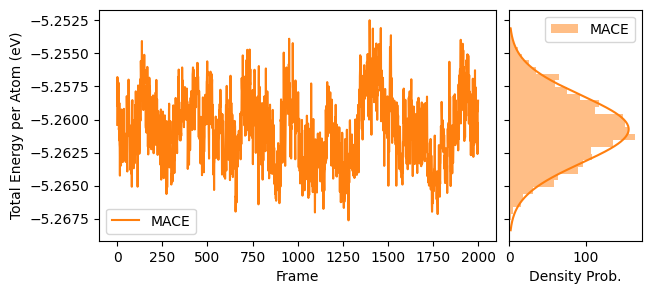

In [ ]:
from aseMolec import extAtoms as ea

traj = read('/content/drive/MyDrive/QuimQuanticaComp/mace_MD/producao_mace_md_sI_CO2_260-K.xyz', index=':')
# traj = read('file.xyz', index=':')

# cortando a parte inicial da simulação (fora do equilíbrio)
# traj = traj0[600:]
frames = np.arange(len(traj))
mace_energies = ea.get_prop(traj, 'info', 'energy_mace', peratom=True)

fig, axs = plt.subplots(1, 2,figsize=(7,3), sharey=True, gridspec_kw={'width_ratios': [3, 1], 'wspace': 0.05} )

axs[0].plot(frames, mace_energies, label='MACE', color='C1')
axs[0].legend()
axs[0].set_xlabel('Frame')
axs[0].set_ylabel('Total Energy per Atom (eV)')

axs[1].hist(mace_energies,bins=30,density=True, color='C1', alpha=0.5, label='MACE', orientation="horizontal")

Umean = np.mean(mace_energies)
sigmaU = np.std(mace_energies)
uarray = Umean+np.arange(-3*sigmaU,3*sigmaU,0.01*sigmaU)
axs[1].plot(np.sqrt(1/(2*np.pi*sigmaU**2))*np.exp(-0.5*(uarray-Umean)**2/sigmaU**2),uarray, color='C1')

axs[1].legend()
axs[1].set_xlabel('Density Prob.')

Text(0.5, 0, 'Density Prob.')

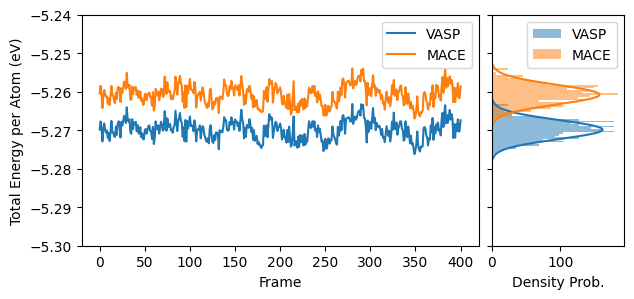

In [ ]:
from aseMolec import extAtoms as ea

traj = read('/content/drive/MyDrive/QuimQuanticaComp/mace_MD/mace_vs_vasp_md_sI_CO2_260-K.xyz', ':')
frames = np.arange(len(traj))
vasp_energies = ea.get_prop(traj, 'info', 'energy_vasp', peratom=True)
mace_energies = ea.get_prop(traj, 'info', 'energy_mace', peratom=True)

fig, axs = plt.subplots(1, 2,figsize=(7,3), sharey=True, gridspec_kw={'width_ratios': [3, 1], 'wspace': 0.05} )

# limites com margem extra
# Ajuste manual do eixo y (energia)
axs[0].set_ylim(-5.3, -5.24)


axs[0].plot(frames, vasp_energies, label='VASP')
axs[0].plot(frames, mace_energies, label='MACE')
axs[0].legend()
axs[0].set_xlabel('Frame')
axs[0].set_ylabel('Total Energy per Atom (eV)')

axs[1].hist(vasp_energies,bins=30,density=True, color='C0', alpha=0.5, label='VASP', orientation="horizontal")
axs[1].hist(mace_energies,bins=30,density=True, color='C1', alpha=0.5, label='MACE', orientation="horizontal")

Umean = np.mean(vasp_energies)
sigmaU = np.std(vasp_energies)
uarray = Umean+np.arange(-3*sigmaU,3*sigmaU,0.01*sigmaU)
axs[1].plot(np.sqrt(1/(2*np.pi*sigmaU**2))*np.exp(-0.5*(uarray-Umean)**2/sigmaU**2),uarray, color='C0')
Umean = np.mean(mace_energies)
sigmaU = np.std(mace_energies)
uarray = Umean+np.arange(-3*sigmaU,3*sigmaU,0.01*sigmaU)
axs[1].plot(np.sqrt(1/(2*np.pi*sigmaU**2))*np.exp(-0.5*(uarray-Umean)**2/sigmaU**2),uarray, color='C1')
axs[1].legend()
axs[1].set_xlabel('Density Prob.')

In [ ]:
RMSE = np.sqrt(np.mean((mace_energies-vasp_energies)**2))

print("RMSE entre energias do MACE e VASP: {:.3f} eV/átomo".format(RMSE))

RMSE entre energias do MACE e VASP: 0.009 eV/átomo


In [ ]:
vasp_forces = ea.get_prop(traj, 'arrays', 'forces_vasp', peratom=True)
mace_forces = ea.get_prop(traj, 'arrays', 'forces_mace', peratom=True)

RMSE_forces = np.sqrt(np.mean((mace_forces-vasp_forces)**2))

print("RMSE entre forças do MACE e VASP: {:.4f} eV/Å".format(RMSE_forces))

RMSE entre forças do MACE e VASP: 0.0004 eV/Å
